# Task 7: Detect coins with Hough circles

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = 'images/coins.jpg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
img.shape

(129, 192, 3)

In [3]:
blurred = cv2.medianBlur(gray, 5)

settings = [10, 16, 30]
panels = [('Original', img)]
counts = {}

for p2 in settings:
    circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, 1, minDist=30, param1=100, param2=p2, minRadius=15, maxRadius=40)
    circles = np.round(circles.reshape(-1, 3)).astype(int)
    result = img.copy()
    for x, y, r in circles:
        cv2.circle(result, (x, y), r, (0, 255, 0), 2)
        cv2.circle(result, (x, y), 2, (255, 0, 0), 3)
    counts[p2] = len(circles)
    print(f'param2={p2} - coins counted:', len(circles))
    panels.append((f'param2={p2}: {len(circles)} coins', result))

param2=10 - coins counted: 11
param2=16 - coins counted: 5
param2=30 - coins counted: 4


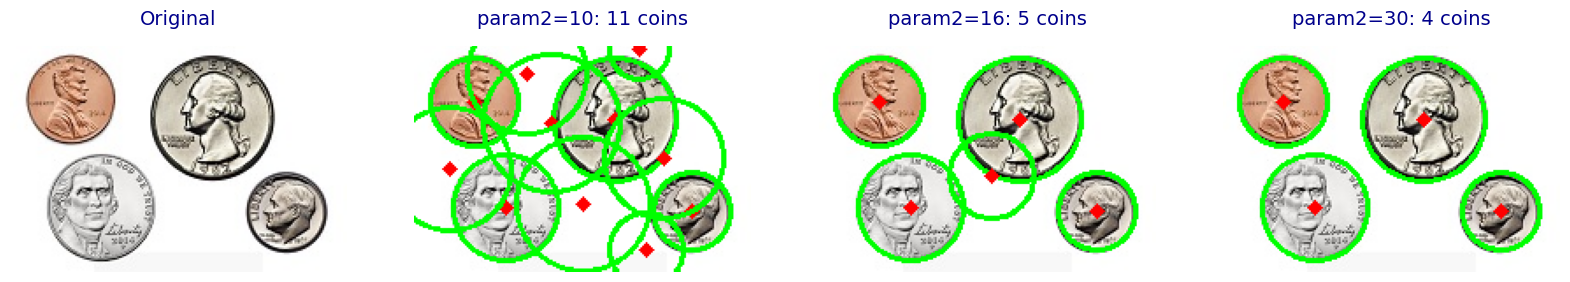

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im)
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()